# **PHÂN CỤM K-MEAN TRÊN TẬP DỮ LIỆU MALL-CUSTOMER**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv('Mall_Customers.csv')
# Transform Gender to 0's and 1's 

data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data.info()

# Data for cluster
X = data.iloc[:, -4:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


Xây dựng mô hình K-Means 

In [3]:
km_inertias, km_scores = [], []
for k in range(3,10):
    km = KMeans(n_clusters=k).fit(X)
    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(X, km.labels_))
    print(f'Processing K-means with k = {k}, Intertia = {km.inertia_}, Silhoutte Score = {silhouette_score(X, km.labels_)}')

km_inertias

Processing K-means with k = 3, Intertia = 143391.59236035674, Silhoutte Score = 0.383798873822341
Processing K-means with k = 4, Intertia = 105299.98742210324, Silhoutte Score = 0.3921703094115865
Processing K-means with k = 5, Intertia = 75542.77371510219, Silhoutte Score = 0.43959178858284587
Processing K-means with k = 6, Intertia = 72107.6348794446, Silhoutte Score = 0.40411944768980895
Processing K-means with k = 7, Intertia = 51147.01731797614, Silhoutte Score = 0.4400035911705477
Processing K-means with k = 8, Intertia = 48579.457773685885, Silhoutte Score = 0.39071706492480307
Processing K-means with k = 9, Intertia = 40663.67315640882, Silhoutte Score = 0.41457740954617534


[143391.59236035674,
 105299.98742210324,
 75542.77371510219,
 72107.6348794446,
 51147.01731797614,
 48579.457773685885,
 40663.67315640882]

Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow 

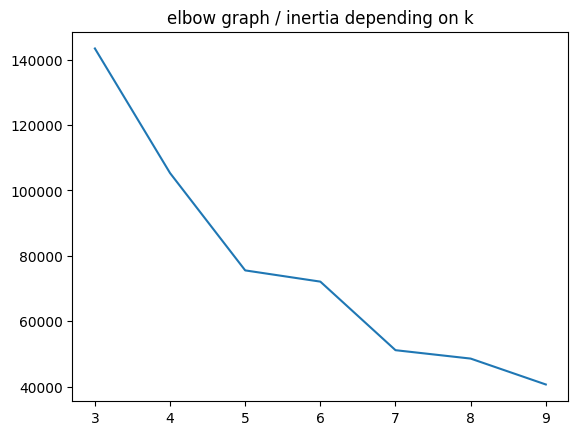

In [4]:
sns.lineplot(x=range(3,10), y = km_inertias)
plt.title('elbow graph / inertia depending on k')
plt.show()
plt.close()

 Tìm số cụm tối ưu bằng phương pháp Silhoutte

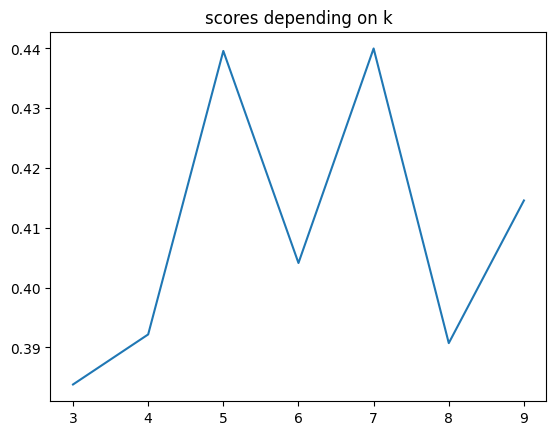

In [5]:
sns.lineplot(x=range(3, 10), y=km_scores)
plt.title('scores depending on k')
plt.show()
plt.close()

Gán nhãn cho các mẫu dữ liệu dựa vào mô hình K-Means với số cụm là 6

In [6]:
X['Label'] = km.labels_

for k in range(6):
    print(f'Cluster nb:{k}')
    print(X[X.Label == k].describe().iloc[:, 1:-1])
    print ('\n\n')

Cluster nb:0
             Age  Annual Income (k$)  Spending Score (1-100)
count  10.000000           10.000000               10.000000
mean   41.000000          109.700000               22.000000
std     7.118052           13.768321                9.140873
min    32.000000           97.000000                8.000000
25%    34.750000           99.500000               16.250000
50%    41.000000          103.000000               20.500000
75%    45.750000          118.250000               27.000000
max    54.000000          137.000000               39.000000



Cluster nb:1
             Age  Annual Income (k$)  Spending Score (1-100)
count  44.000000           44.000000               44.000000
mean   56.340909           53.704545               49.386364
std     8.550651            8.239382                5.993081
min    43.000000           38.000000               35.000000
25%    49.000000           47.000000               45.750000
50%    54.000000           54.000000               49.00